# Modelling expected bakery provision across London MSOAs

This notebook estimates expected bakery counts across 1,002 Greater London MSOAs.

For each of the three definitions, resident population is used as a proxy for local demand and active NaPTAN transport nodes are used as a proxy for accessibility.

Poisson regression is fitted as a count-model baseline. Negative Binomial regression is later used to account for substantial overdispersion that was identified in the exploratory analysis.

Observed and expected counts will later be compared identify relative under-provision.

In [1]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


DATA_DATE = "2026-07-23"

SPATIAL_PROCESSED_FOLDER = Path("../data/spatial/processed")

MODELLING_PATH = (SPATIAL_PROCESSED_FOLDER / f"london_msoa_modelling_dataset_{DATA_DATE}.csv")

TABLE_FOLDER = Path("../outputs/tables")
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

MODEL_OUTPUT_FOLDER = Path("../outputs/models")
MODEL_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

FIGURE_FOLDER = Path("../outputs/figures")
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

## Load and prepare the modelling data

The modelling dataset produced in Notebook 15 is loaded.

Population and transport provision are rescaled to make later coefficients easier to interpret.

In [2]:
model_data = pd.read_csv(MODELLING_PATH, low_memory=False)

outcome_columns = {"Core only": "core_bakery_count",
                   "Core and café": "core_and_cafe_count",
                   "All provision included": "bakery_count"}

required_columns = ["msoa_code",
                    "msoa_name",
                    "borough_name",
                    "population",
                    "transport_nodes",
                    "core_bakery_count",
                    "core_and_cafe_count",
                    "bakery_count"]

missing_values = model_data[required_columns].isna().sum().sum()

print(f"MSOA rows: {len(model_data)}")
print(f"Unique MSOA codes: {model_data['msoa_code'].nunique()}")
print(f"Missing required values: {missing_values}")

if model_data["msoa_code"].duplicated().any():
    raise RuntimeError("Duplicate MSOA codes found.")

if missing_values > 0:
    raise RuntimeError("Missing values found in required modelling columns.")

model_data["population_1000"
           ] = (model_data["population"] / 1000)

model_data["log_transport_nodes"
           ] = np.log1p(model_data["transport_nodes"])

display(model_data[["population",
                    "population_1000",
                    "transport_nodes",
                    "log_transport_nodes",
                    "core_bakery_count",
                    "core_and_cafe_count",
                    "bakery_count"]]
                    .describe().round(2))

MSOA rows: 1002
Unique MSOA codes: 1002
Missing required values: 0


,population,population_1000,transport_nodes,log_transport_nodes,core_bakery_count,core_and_cafe_count,bakery_count
count,1002.00,1002.00,1002.00,1002.00,1002.00,1002.00,1002.00
mean,9071.59,9.07,22.78,3.03,0.92,2.92,5.17
std,1958.13,1.96,15.27,0.52,1.80,6.64,7.90
min,5274.00,5.27,0.00,0.00,0.00,0.00,0.00
25%,7684.00,7.68,14.00,2.71,0.00,0.00,1.00
50%,8747.00,8.75,20.00,3.04,0.00,1.00,3.00
75%,10122.75,10.12,28.00,3.37,1.00,3.00,7.00
max,16767.00,16.77,235.00,5.46,31.00,114.00,129.00


## Model specification

Bakery counts are modelled using:
- resident population
- active transport nodes

The same predictors are used for all three bakery definitions so that the results remain directly comparable.

## Poisson regression

In [3]:
poisson_models = {}
poisson_results = []

for definition, outcome in outcome_columns.items():
    formula = (f"{outcome} ~ population_1000 + log_transport_nodes")

    model = smf.glm(formula = formula,
                    data = model_data,
                    family = sm.families.Poisson()).fit()

    poisson_models[definition] = model

    dispersion = model.pearson_chi2 / model.df_resid

    poisson_results.append({"Definition": definition,
                            "AIC": model.aic,
                            "Log-likelihood": model.llf,
                            "Dispersion": dispersion})

poisson_comparison = pd.DataFrame(poisson_results)

display(poisson_comparison.round({"AIC": 2,
                                  "Log-likelihood": 2,
                                  "Dispersion": 2}))

,Definition,AIC,Log-likelihood,Dispersion
0,Core only,2851.54,-1422.77,2.07
1,Core and café,6203.33,-3098.66,5.67
2,All provision included,7499.18,-3746.59,5.47


## Negative Binomial regression

The exploratory analysis showed a considerably larger variance for bakery count than the mean for all three definitions.

Alpha represents the additional dispersion estimated by the Negative Binomial model (where values close to zero indicate that Poisson may have been sufficient and larger positive values indicate additional variation that Poisson could not accommodate).

In [4]:
negative_binomial_models = {}
negative_binomial_results = []

for definition, outcome in outcome_columns.items():

    formula = (f"{outcome} ~ population_1000 + log_transport_nodes")

    model = smf.negativebinomial(formula = formula, 
                                 data = model_data).fit(disp=False, maxiter=200)

    negative_binomial_models[definition] = model

    negative_binomial_results.append({"Definition": definition,
                                      "AIC": model.aic,
                                      "Log-likelihood": model.llf,
                                      "Alpha": model.params["alpha"]})

negative_binomial_comparison = pd.DataFrame(negative_binomial_results)

display(negative_binomial_comparison.round({"AIC": 2,
                                            "Log-likelihood": 2,
                                            "Alpha": 3}))

,Definition,AIC,Log-likelihood,Alpha
0,Core only,2558.37,-1275.18,1.120
1,Core and café,4208.66,-2100.33,1.253
2,All provision included,5270.81,-2631.41,0.728


## Compare model fit

Poisson and Negative Binomial models are compared using the Akaike Information Criterion (AIC), where lower AIC is a better model fit.

In [5]:
model_comparison = (poisson_comparison[["Definition", "AIC", "Dispersion"]]
                    .rename(columns={"AIC": "Poisson AIC",
                                     "Dispersion": "Poisson dispersion"})
                    .merge(negative_binomial_comparison[["Definition", "AIC", "Alpha"]]
                           .rename(columns={"AIC": "Negative Binomial AIC",
                                            "Alpha": "Negative Binomial alpha"}),
                                            on="Definition",
                                            how="left",
                                            validate="one_to_one"))

model_comparison["AIC reduction"
                 ] = (model_comparison["Poisson AIC"] - model_comparison["Negative Binomial AIC"])

display(model_comparison.round({"Poisson AIC": 2,
                                "Poisson dispersion": 2,
                                "Negative Binomial AIC": 2,
                                "Negative Binomial alpha": 3,
                                "AIC reduction": 2}))

,Definition,Poisson AIC,Poisson dispersion,Negative Binomial AIC,Negative Binomial alpha,AIC reduction
0,Core only,2851.54,2.07,2558.37,1.120,293.17
1,Core and café,6203.33,5.67,4208.66,1.253,1994.67
2,All provision included,7499.18,5.47,5270.81,0.728,2228.37


## Negative Binomial model results

Negative Binomial regression produced substantially lower AIC values. It is therefore selected for estimating expected bakery counts.

The coefficients are converted into incidence rate ratios to make the effects easier to interpret.

In [6]:
predictor_settings = {"population_1000": {"label": "Additional 1,000 residents",
                                          "change": 1},
                      "log_transport_nodes": {"label": "Approximate doubling of transport nodes",
                                              "change": np.log(2)}}


coefficient_rows = []

for definition, model in negative_binomial_models.items():
    confidence_intervals = model.conf_int()

    for predictor, settings in predictor_settings.items():
        change = settings["change"]
        
        incidence_rate_ratio = np.exp(model.params[predictor] * change)

        confidence_lower = np.exp(confidence_intervals.loc[predictor, 0] * change)

        confidence_upper = np.exp(confidence_intervals.loc[predictor, 1] * change)

        coefficient_rows.append({"Definition": definition,
                                 "Predictor": settings["label"],
                                 "Incidence rate ratio": incidence_rate_ratio,
                                 "Expected count change (%)": (incidence_rate_ratio - 1) * 100,
                                 "95% CI lower": confidence_lower,
                                 "95% CI upper": confidence_upper,
                                 "p-value": model.pvalues[predictor]})

coefficient_table = pd.DataFrame(coefficient_rows)

display(coefficient_table.round({"Incidence rate ratio": 3,
                                 "Expected count change (%)": 1,
                                 "95% CI lower": 3,
                                 "95% CI upper": 3,
                                 "p-value": 4}))

,Definition,Predictor,Incidence rate ratio,Expected count change (%),95% CI lower,95% CI upper,p-value
0,Core only,"Additional 1,000 residents",0.986,-1.4,0.939,1.035,0.5623
1,Core only,Approximate doubling of transport nodes,1.812,81.2,1.606,2.045,0.0000
2,Core and café,"Additional 1,000 residents",0.980,-2.0,0.941,1.020,0.3215
3,Core and café,Approximate doubling of transport nodes,1.899,89.9,1.724,2.092,0.0000
4,All provision included,"Additional 1,000 residents",1.033,3.3,1.002,1.065,0.0349
5,All provision included,Approximate doubling of transport nodes,1.695,69.5,1.571,1.828,0.0000


## Expected counts and model checks

Expected bakery counts are generated using the Negative Binomial models.

Observed and expected mean counts are compared along with the number of zero-count MSOAs. It provides a quick check of how the selected models represent the three outcome distributions.

In [7]:
prediction_summary_rows = []

for definition, outcome in outcome_columns.items():
    model = negative_binomial_models[definition]

    expected_column = f"expected_{outcome}"

    model_data[expected_column] = model.predict(model_data)

    observed = model_data[outcome]
    expected = model_data[expected_column]

    alpha = model.params["alpha"]

    zero_probabilities = (1 + alpha * expected) ** (-1 / alpha)

    prediction_summary_rows.append({"Definition": definition,
                                    "Observed mean": observed.mean(),
                                    "Expected mean": expected.mean(),
                                    "Observed maximum": observed.max(),
                                    "Expected maximum": expected.max(),
                                    "Observed zero MSOAs": observed.eq(0).sum(),
                                    "Model-estimated zero MSOAs": zero_probabilities.sum(),
                                    "Mean absolute error": (observed - expected).abs().mean()})

prediction_summary = pd.DataFrame(prediction_summary_rows)

display(prediction_summary.round({"Observed mean": 2,
                                  "Expected mean": 2,
                                  "Expected maximum": 2,
                                  "Model-estimated zero MSOAs": 1,
                                  "Mean absolute error": 2}))

,Definition,Observed mean,Expected mean,Observed maximum,Expected maximum,Observed zero MSOAs,Model-estimated zero MSOAs,Mean absolute error
0,Core only,0.92,0.90,31,6.06,557,558.5,1.01
1,Core and café,2.92,2.77,114,20.79,304,332.1,2.72
2,All provision included,5.17,5.05,129,35.91,120,142.3,3.81


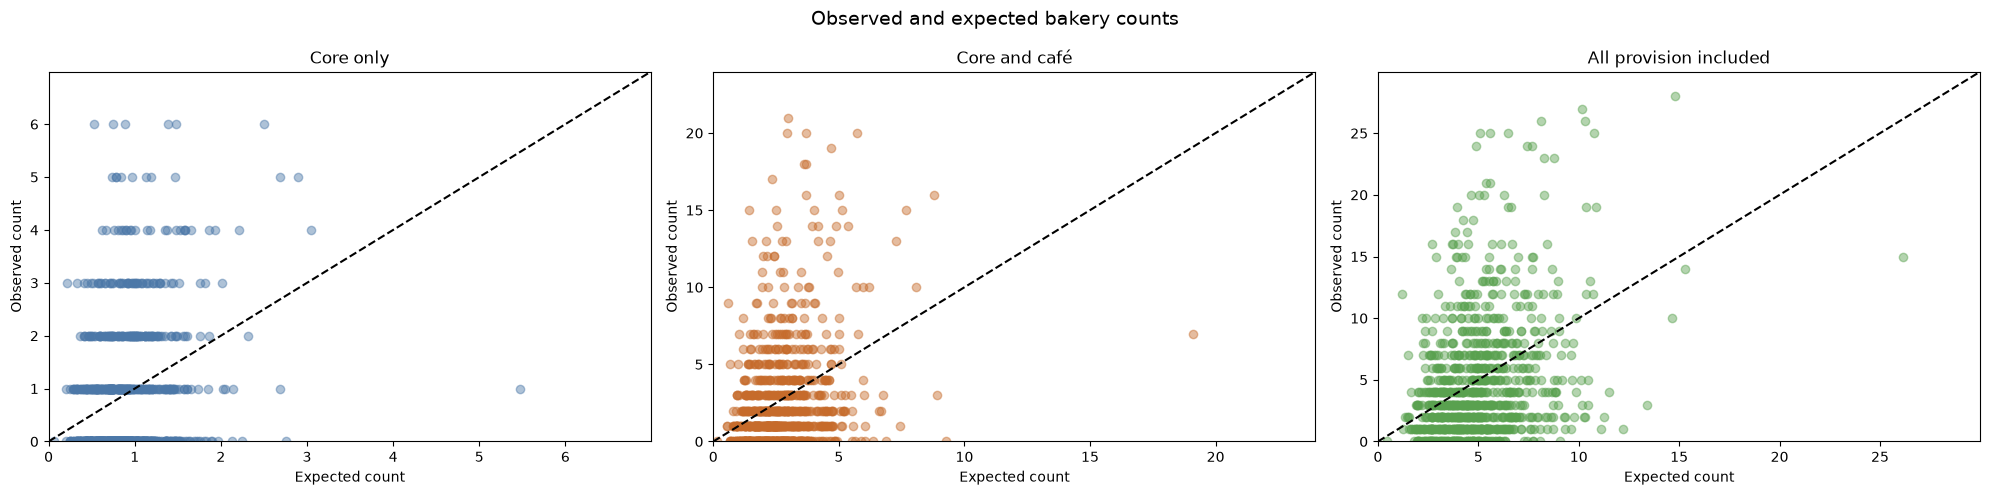

Saved to: ..\outputs\figures\negative_binomial_observed_expected.png


In [8]:
plot_definitions = [("Core only", "core_bakery_count", "expected_core_bakery_count", "#4c78a8"),
                    ("Core and café", "core_and_cafe_count", "expected_core_and_cafe_count", "#c66b2b"),
                    ("All provision included", "bakery_count", "expected_bakery_count", "#59a14f")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for axis, (definition, observed_column, expected_column, colour) in zip(axes, plot_definitions):
    observed = model_data[observed_column]
    expected = model_data[expected_column]

    display_limit = max(observed.quantile(0.99),
                        expected.quantile(0.99))

    display_rows = (observed.le(display_limit)
                    & expected.le(display_limit))

    axis.scatter(expected[display_rows],
                 observed[display_rows],
                 alpha=0.45, 
                 color=colour)

    axis.plot([0, display_limit],
              [0, display_limit],
              linestyle="--",
              color="black")

    axis.set_xlim(0, display_limit)
    axis.set_ylim(0, display_limit)

    axis.set_title(definition)
    axis.set_xlabel("Expected count")
    axis.set_ylabel("Observed count")

fig.suptitle("Observed and expected bakery counts", fontsize=14)

plt.tight_layout()

model_fit_figure_path = (FIGURE_FOLDER / "negative_binomial_observed_expected.png")
plt.savefig(model_fit_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {model_fit_figure_path}")

# Save model outputs

In [9]:
MODEL_PREDICTION_PATH = (MODEL_OUTPUT_FOLDER / f"london_msoa_bakery_model_predictions_{DATA_DATE}.csv")
MODEL_COMPARISON_PATH = (TABLE_FOLDER / f"bakery_count_model_comparison_{DATA_DATE}.csv")
COEFFICIENT_PATH = (TABLE_FOLDER / f"negative_binomial_coefficients_{DATA_DATE}.csv")
PREDICTION_SUMMARY_PATH = (TABLE_FOLDER / f"negative_binomial_prediction_summary_{DATA_DATE}.csv")

model_data.to_csv(MODEL_PREDICTION_PATH, index=False, encoding="utf-8-sig")
model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False, encoding="utf-8-sig")
coefficient_table.to_csv(COEFFICIENT_PATH, index=False, encoding="utf-8-sig")
prediction_summary.to_csv(PREDICTION_SUMMARY_PATH, index=False, encoding="utf-8-sig")

print(f"Model predictions saved to: {MODEL_PREDICTION_PATH}")
print(f"Model comparison saved to: {MODEL_COMPARISON_PATH}")
print(f"Coefficient table saved to: {COEFFICIENT_PATH}")
print(f"Prediction summary saved to: {PREDICTION_SUMMARY_PATH}")

Model predictions saved to: ..\outputs\models\london_msoa_bakery_model_predictions_2026-07-23.csv
Model comparison saved to: ..\outputs\tables\bakery_count_model_comparison_2026-07-23.csv
Coefficient table saved to: ..\outputs\tables\negative_binomial_coefficients_2026-07-23.csv
Prediction summary saved to: ..\outputs\tables\negative_binomial_prediction_summary_2026-07-23.csv
